# Load the necessary modules

In [1]:
import tifffile
import matplotlib.pyplot as plt
from selfphish.utils import nor_phase
from selfphish.ganrec import GANphase

2025-07-18 13:30:52.810768: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752859853.995894 4082326 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752859854.167117 4082326 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752859857.080886 4082326 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752859857.080934 4082326 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752859857.080941 4082326 computation_placer.cc:177] computation placer alr

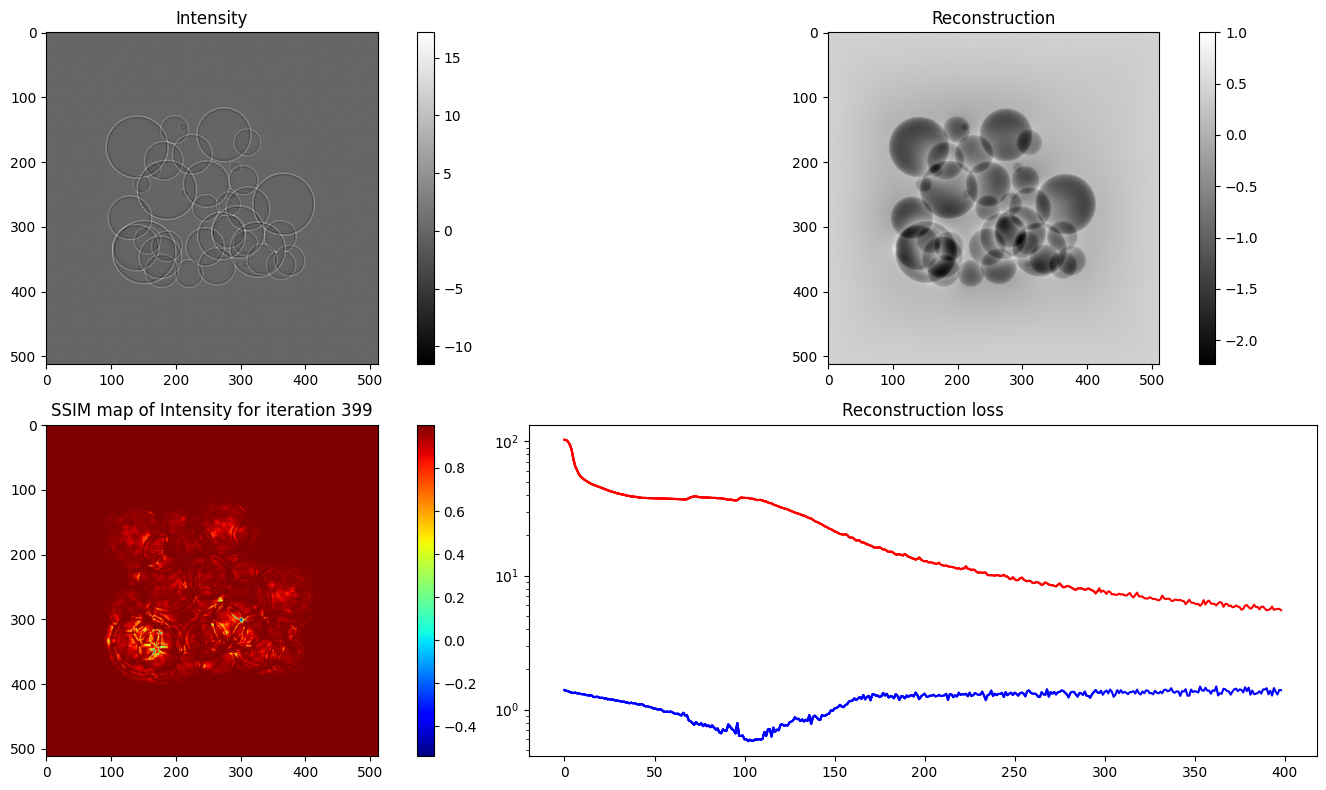

<Figure size 640x480 with 0 Axes>

Reconstruction Progress:  23%|██▎       | 459/2000 [00:18<00:43, 35.84it/s, D_loss=1.35, G_loss=5.01]

In [ ]:
energy = 15 # in keV
z = 0.001 # in m
pv = 1e-7 # in m
iter_num = 2000
fname_data = '/nsls2/data/staff/xyang4/data/phase_sim/original_data/2d_360_z001-50.tif'
tifffile.imwrite('./test_data/sphere_hologram_e15_z001_p1e-7.tiff', tifffile.imread(fname_data)[0])
data = tifffile.imread(fname_data)[0]
data = nor_phase(data)
abs, phase = GANphase(data, energy, z, pv, abs_ratio=0.5, iter_num=iter_num).recon

# Subplot both phase and abs
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
im0 = axs[0].imshow(phase)
axs[0].set_title('Phase')
fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)
im1 = axs[1].imshow(abs)
axs[1].set_title('Absorption')
fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

tifffile.imwrite('./test_results/sphere_phase_e15_z001_p1e-7.tiff', phase)
tifffile.imwrite('./test_results/sphere_abs_e15_z001_p1e-7.tiff', abs)

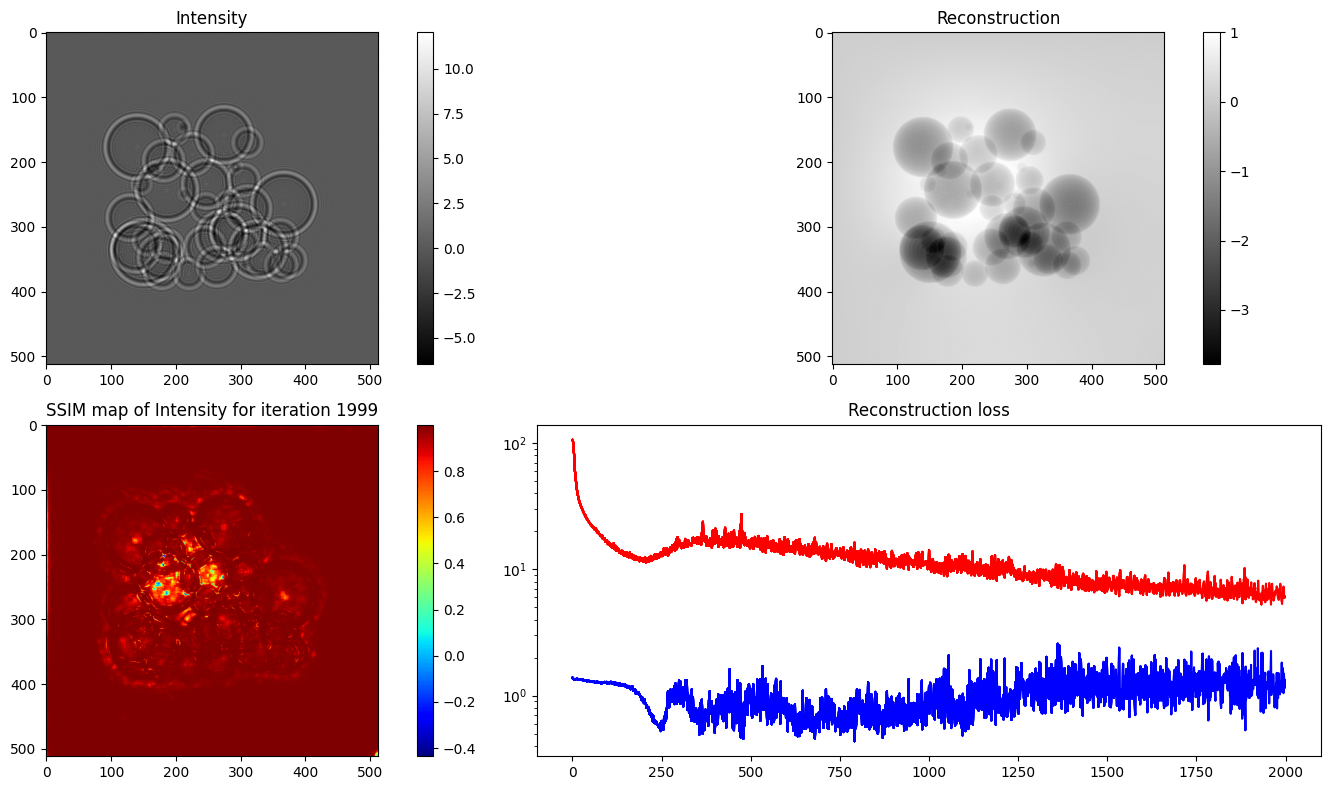

<Figure size 640x480 with 0 Axes>

Reconstruction Progress: 100%|█████████▉| 1999/2000 [01:09<00:00, 36.51it/s, D_loss=1.03, G_loss=6.38]

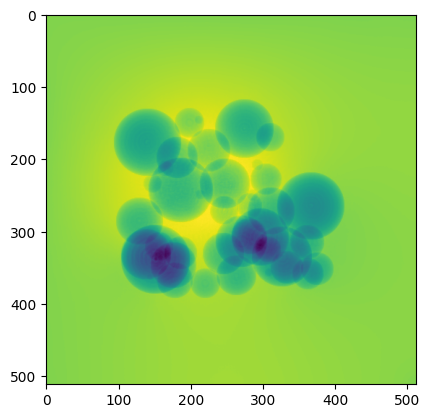

Reconstruction Progress: 100%|██████████| 2000/2000 [01:23<00:00, 36.51it/s, D_loss=1.03, G_loss=6.38]

In [7]:
energy = 15 # in keV
z = 0.005 # in m
pv = 1e-7 # in m
iter_num = 2000
fname_data = '/nsls2/data/staff/xyang4/data/phase_sim/original_data/2d_360_z001-50.tif'
tifffile.imwrite('./test_data/sphere_hologram_e15_z005_p1e-7.tiff', tifffile.imread(fname_data)[1])
data = tifffile.imread(fname_data)[1]
data = nor_phase(data)
abs, phase = GANphase(data, energy, z, pv, abs_ratio=0.5, iter_num=iter_num).recon
plt.imshow(phase)
plt.show()
tifffile.imwrite('./test_results/sphere_phase_e15_z005_p1e-7.tiff', phase)
tifffile.imwrite('./test_results/sphere_abs_e15_z005_p1e-7.tiff', abs)

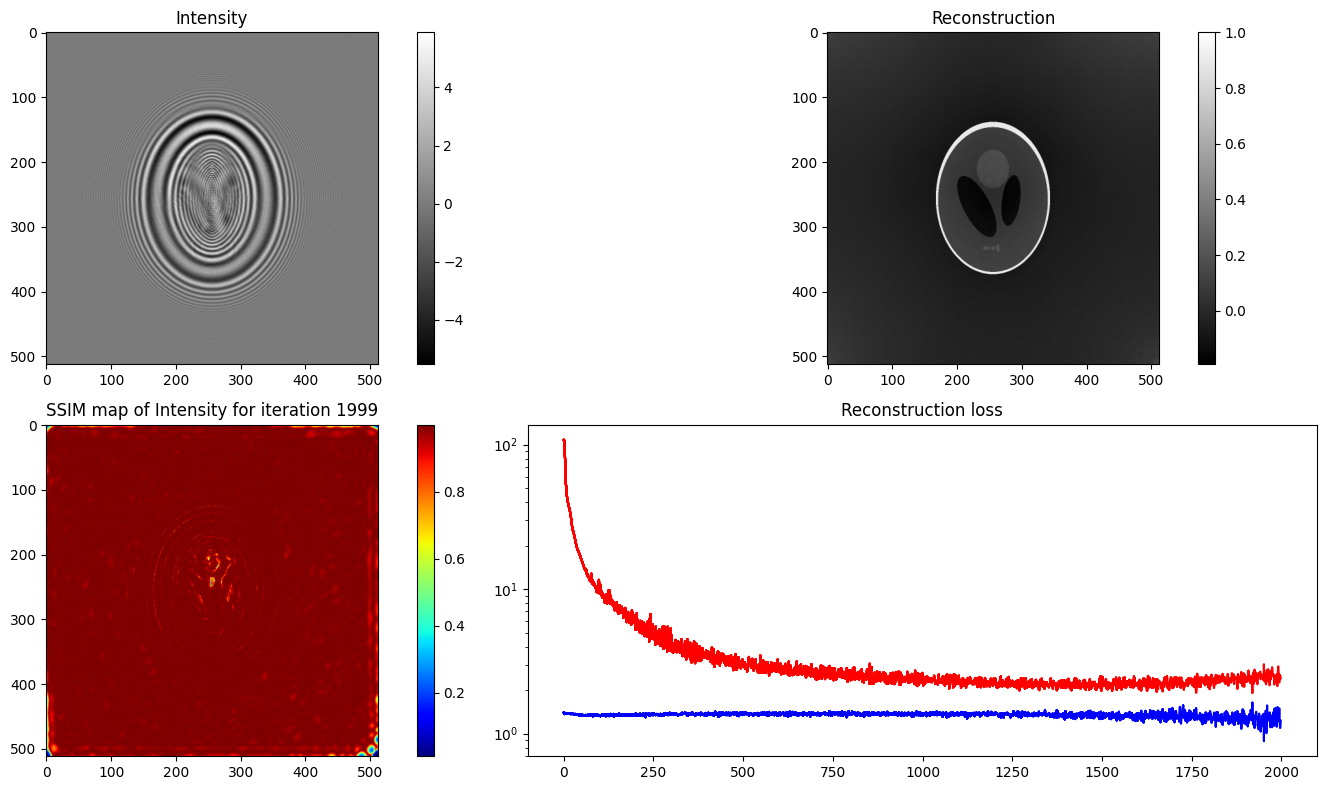

<Figure size 640x480 with 0 Axes>

Reconstruction Progress: 100%|█████████▉| 1999/2000 [01:12<00:00, 36.99it/s, D_loss=1.43, G_loss=2.58]

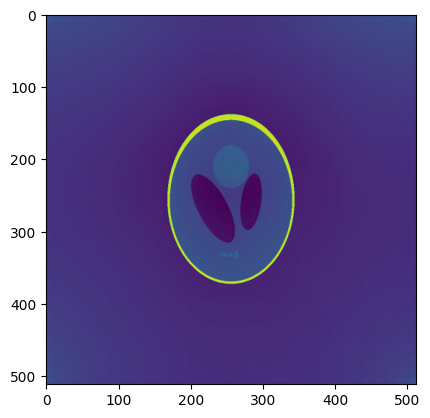

In [2]:
energy = 10
z = 0.5
pv = 5e-7
iter_num = 2000
fname_data = './test_data/hologram_shepp.tiff'
data = tifffile.imread(fname_data)
data = nor_phase(data)
abs, phase = GANphase(data, energy, z, pv, iter_num=iter_num).recon
plt.imshow(phase)
plt.show()
tifffile.imwrite('./test_results/phase_shepp.tiff', phase)

# Reconstruct the phase with GANrec and save the result

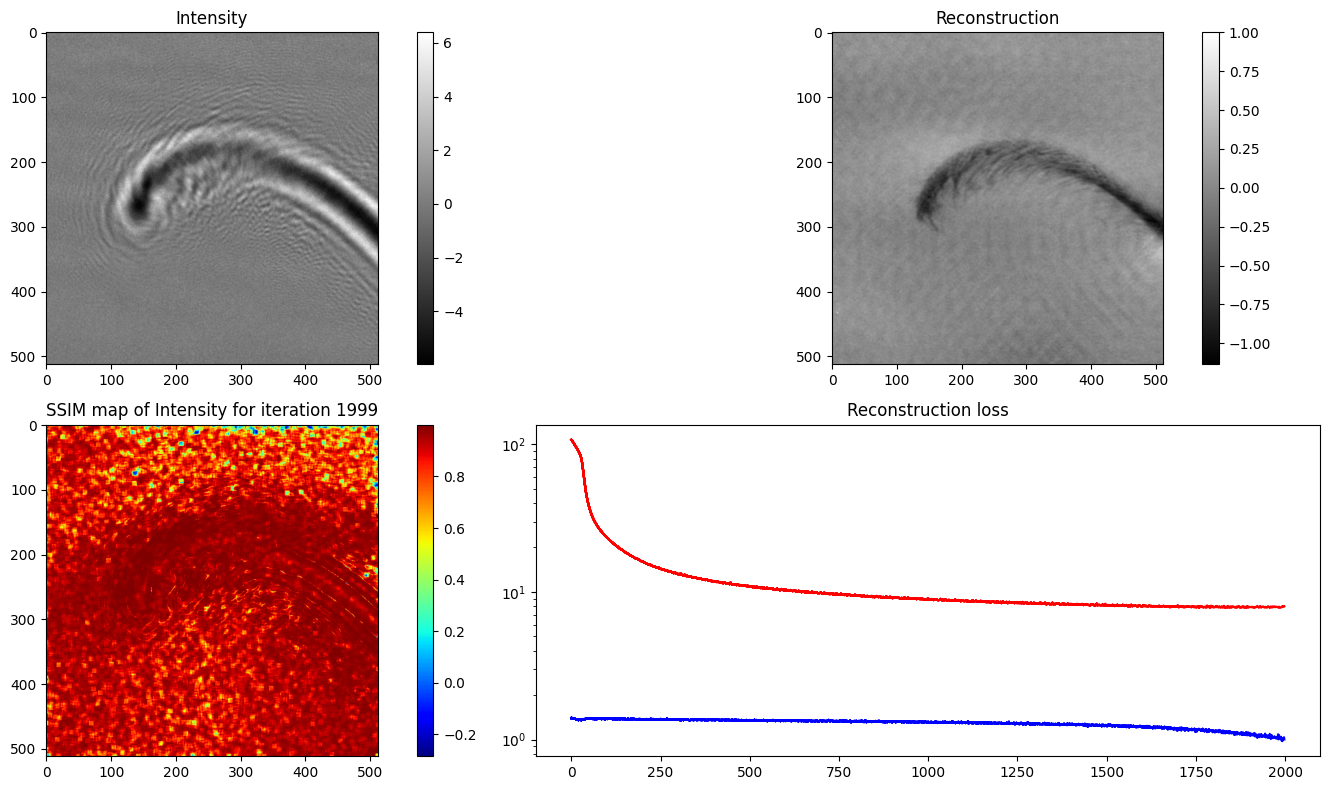

<Figure size 640x480 with 0 Axes>

Reconstruction Progress: 100%|█████████▉| 1999/2000 [01:08<00:00, 36.81it/s, D_loss=0.999, G_loss=7.91]

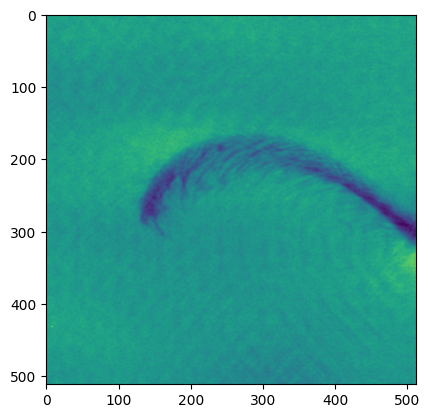

Reconstruction Progress: 100%|██████████| 2000/2000 [01:26<00:00, 36.81it/s, D_loss=0.999, G_loss=7.91]

In [ ]:
energy = 11
z = 7.8880960e-2
pv = 1.04735263e-7
abs_ratio = 0.08
iter_num = 2000
g_learning_rate = 1e-4
d_learning_rate = 1e-6
fname_data = './test_data/hologram_spider_hair.tiff'
data = tifffile.imread(fname_data)
data = nor_phase(data)
abs, phase = GANphase(data, energy, z, pv, abs_ratio = abs_ratio, 
                      iter_num=iter_num, 
                      g_learning_rate = g_learning_rate,
                      d_learning_rate = d_learning_rate).recon
plt.imshow(phase)
plt.show()
tifffile.imwrite('./test_results/spider_hair.tiff', phase)